## Extract the spectrum from the residuals obtained using the Neural Network

Two pipelines here:

1) - Load the desired real data (e.g. **30477**)
   - Extract the images from each of 16 detectors
   - Cut each into 512x512 patches, with no overlap (add a black border to reach 2048x2048)
   - Feed those to the neural network and compute the residuals
   - Put the 16 images back together (from 512x512 to 2040x2040)

---
2) - Create a new frame with RA, DEC and PA equal to those of the desired pointing (e.g. **30477**)
   - Populate each detector with the corresponding residual image
   - Apply the routine for spectrum extraction
   - Compare with the one obtained with the medial filter

In [1]:
import gelsa
from gelsa.sgs import datastore
from matplotlib import pyplot as plt
from gelsa import visu
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Rescaling
from astropy.table import Table
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits

2025-12-05 16:00:38.133963: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 16:00:38.174419: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-05 16:00:38.174443: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-05 16:00:38.174449: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-05 16:00:38.180686: I tensorflow/core/platform/cpu_feature_g

In [2]:
pt_id = 30477

In [3]:
DS = datastore.DataStore(username='', password='',
                        cachedir='/scratch/astro/benjamin.granett/datastore'
                        )


# Load the data related to the pointing_id
file_list = DS.load_sir_pack("DR1_R1", pointing_id_list=[pt_id])
# Create a Gelsa object
G = gelsa.Gelsa(config_file="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/gelsa_config.json", 
                calibdir="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/", zero_order_catalog=None)
# Define the frame associated to the pointing
frame = G.load_spec_frame(**file_list[0])

got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30477, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30477'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml


In [4]:
pointing_filename = "/scratch/astro/nicolo.fiaba/pointing_list.txt"
pointings = Table.read(pointing_filename, format='ascii')

In [5]:
pointings[:4]

Data.ObservationSequence.ObservationId,Data.ObservationSequence.PatchId,Data.ObservationSequence.PointingId,Data.ObservationSequence.DitherObservation,Data.AdjustedPointing.RA,Data.AdjustedPointing.Dec,Data.AdjustedPointing.PositionAngle,Data.Grism,Data.GrismWheelTilt
int64,int64,int64,int64,float64,float64,float64,str6,float64
6884,151,30418,0,269.559379037778,66.8387937332167,83.9203554623536,RGS000,0.0
6884,151,30419,1,269.52571079734,66.8070672069503,83.8893506491384,RGS180,4.0
6884,151,30421,3,269.499456487825,66.7435837551837,83.8657315616846,RGS180,0.0
6884,151,30420,2,269.533642830689,66.7761535007858,83.8942986645886,RGS000,-4.0


In [6]:
pt_id_num = np.where(pointings["Data.ObservationSequence.PointingId"] == pt_id)[0][0]
grism = pointings["Data.Grism"][pt_id_num]
grism_tilt = pointings["Data.GrismWheelTilt"][pt_id_num]
print(grism, grism_tilt)

RGS180 0.0


In [7]:
pt_ra = pointings["Data.AdjustedPointing.RA"][pt_id_num]
pt_dec = pointings["Data.AdjustedPointing.Dec"][pt_id_num]
pt_pa = pointings["Data.AdjustedPointing.PositionAngle"][pt_id_num]

In [8]:
print(f"Pointing {pt_id} RA: {pt_ra}")
print(f"Pointing {pt_id} DEC: {pt_dec}")
print(f"Pointing {pt_id} PA: {pt_pa}")

Pointing 30477 RA: 273.083815984625
Pointing 30477 DEC: 66.8544697333097
Pointing 30477 PA: 87.1513911774078


In [9]:
masks = np.zeros((16, 2040, 2040))
variance = np.zeros((16, 2040, 2040))
detector_imgs = np.zeros((16, 2040, 2040))

for d in range(16):
    im, msk, vr = frame.get_detector(d)
    masks[d, :, :] = msk 
    variance[d, :, :] = vr 
    detector_imgs[d, :, :] = im 

In [10]:
masks[masks > 0] = 1 # Now only 0 and 1 in masks: we don't care about the value, which is a flag in binary

# Apply the mask to the images: where masks is = 1, set the pixel to NaN
detector_imgs[masks == 1] = np.nan

> In `detector_imgs` we have the 16 detectors real data, with NaNs

In [11]:
print(np.sum(np.isnan(detector_imgs)), "NaN pixels in total")

5500966 NaN pixels in total


In [12]:
"""
Preprocessing function for rescaling and stacking
"""
def img_preprocessing(img, mask):
    img_copy = img.copy()
    x_max = np.nanmax(img_copy)
    x_min = np.nanmin(img_copy)
    rescale = Rescaling(1./(x_max - x_min), offset=-x_min/(x_max - x_min), input_shape=(512, 512, 1))
    scaled_img = rescale(img_copy)
    input_imgs = np.stack([scaled_img, mask], axis=-1)

    return input_imgs

In [13]:
input_images = []
for im, msk in zip(detector_imgs, masks):
    input_images.append(img_preprocessing(im, msk))
    
input_images = np.array(input_images)

### Slicing function

In [14]:
# adapted from https://github.com/obss/sahi/blob/e798c80d6e09079ae07a672c89732dd602fe9001/sahi/slicing.py#L30, MIT License
def calculate_slice_bboxes(
    image_height: int = 2048,
    image_width: int = 2048,
    slice_height: int = 512,
    slice_width: int = 512,
    overlap_height_ratio: float = 0.,
    overlap_width_ratio: float = 0.,
) -> list[list[int]]:
    """
    Given the height and width of an image, calculates how to divide the image into
    overlapping slices according to the height and width provided. These slices are returned
    as bounding boxes in xyxy format.
    :param image_height: Height of the original image.
    :param image_width: Width of the original image.
    :param slice_height: Height of each slice
    :param slice_width: Width of each slice
    :param overlap_height_ratio: Fractional overlap in height of each slice (e.g. an overlap of 0.2 for a slice of size 100 yields an overlap of 20 pixels)
    :param overlap_width_ratio: Fractional overlap in width of each slice (e.g. an overlap of 0.2 for a slice of size 100 yields an overlap of 20 pixels)
    :return: a list of bounding boxes in xyxy format
    """

    slice_bboxes = []
    y_max = y_min = 0
    y_overlap = int(overlap_height_ratio * slice_height)
    x_overlap = int(overlap_width_ratio * slice_width)
    while y_max < image_height:
        x_min = x_max = 0
        y_max = y_min + slice_height
        while x_max < image_width:
            x_max = x_min + slice_width
            if y_max > image_height or x_max > image_width:
                xmax = min(image_width, x_max)
                ymax = min(image_height, y_max)
                xmin = max(0, xmax - slice_width)
                ymin = max(0, ymax - slice_height)
                slice_bboxes.append([xmin, ymin, xmax, ymax])
            else:
                slice_bboxes.append([x_min, y_min, x_max, y_max])
            x_min = x_max - x_overlap
        y_min = y_max - y_overlap
    return slice_bboxes

---

Now we want to take each detector image + mask, add a 8 pixel border, slice it with the function and give it to the network

In [15]:
slices = calculate_slice_bboxes()
slices = np.array(slices)

In [16]:
def create_patches(image, slices):
    patches = []
    for ind in range(len(slices)): # Loop over the patches (rows of slices)
        xmin, ymin, xmax, ymax = slices[ind]
        cropped = image[ymin:ymax, xmin:xmax]
        patches.append(cropped)
    patches = np.array(patches)
    return patches

### Add 8 pixel border: 2040x2040 $\rightarrow$ 2048x2048

In [17]:
padded_images = np.pad(input_images, pad_width=(
        (0, 0),   # no padding for detector axis
        (8, 0),   # TOP only (height axis)
        (0, 8),   # RIGHT only (width axis)
        (0, 0)    # no padding for channel axis
    ),
       mode='constant', constant_values=0)

In [18]:
patches = {}

for d, padded in enumerate(padded_images):
    batch = create_patches(padded, slices)
    # Set NaNs to 0
    nonan_batch = tf.where(tf.math.is_nan(batch), 0., batch)
    patches[f'DET:{d}'] = nonan_batch

In [19]:
patches.keys()

dict_keys(['DET:0', 'DET:1', 'DET:2', 'DET:3', 'DET:4', 'DET:5', 'DET:6', 'DET:7', 'DET:8', 'DET:9', 'DET:10', 'DET:11', 'DET:12', 'DET:13', 'DET:14', 'DET:15'])

### Now we can feed each detector **batch** of patches to the Network

In [20]:
!ls /scratch/astro/nicolo.fiaba/trained_models

ATT_UNET_hist_RGS000_0
ATT_UNET_hist_RGS180_0
ATT_UNET_hist_RGS180_4
EL_ATT_UNET_hist_RGS000_0
EL_ATT_UNET_hist_RGS000_minus4
EL_attention_unet_model_RGS000_0.h5
EL_attention_unet_model_RGS000_minus4.h5
attention_unet_model_RGS000_0.h5
attention_unet_model_RGS180_0.h5
attention_unet_model_RGS180_4.h5
denoise_ATT_UNET_hist_RGS000_0
denoise_ATT_UNET_hist_RGS000_minus4
denoise_ATT_UNET_hist_RGS180_0
denoise_ATT_UNET_hist_RGS180_4
denoise_attention_unet_model_RGS000_0.h5
denoise_attention_unet_model_RGS000_minus4.h5
denoise_attention_unet_model_RGS180_0.h5
denoise_attention_unet_model_RGS180_4.h5
long_ATT_UNET_hist_RGS000_0
long_ATT_UNET_hist_RGS180_4
long_attention_unet_model_RGS000_0.h5
long_attention_unet_model_RGS180_4.h5


In [208]:
# Load the model
from keras.models import load_model
saved_model = load_model('/scratch/astro/nicolo.fiaba/trained_models/EL_attention_unet_model_RGS000_0.h5', compile=False)

saved_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss='mse',
                  metrics="mse")

In [209]:
predictions = []

for imgs in patches.values():
    predicted_imgs = saved_model.predict(imgs)
    predictions.append(predicted_imgs)
predictions = np.array(predictions)

1/1 [==============================] - 5s 5s/step


In [210]:
predictions.shape

(16, 16, 512, 512, 1)

(16 detectors, 16 patches, 512 height, 512 width, 1 channel)

### Put back together the processed patches and compute the residuals

In [211]:
def reconstruct_image(patches, slices, image_height=2048, image_width=2048):
    
    full_image = np.zeros((image_height, image_width, patches[0].shape[2]), dtype=patches.dtype)

    for patch, (xmin, ymin, xmax, ymax) in zip(patches, slices):
        full_image[ymin:ymax, xmin:xmax] = patch

    return full_image

In [212]:
pred_detectors = {}

for d, pred in enumerate(predictions):
    recon = reconstruct_image(pred, slices)
    recon = recon[8:, :-8, :] # Crop the 8 pixel borders
    recon = np.squeeze(recon)
    pred_detectors[f'DET:{d}'] = recon

In [213]:
real_detectors = {}

for d, img in enumerate(detector_imgs):
    x_max = np.nanmax(img)
    x_min = np.nanmin(img)
    rescale = Rescaling(1./(x_max - x_min), offset=-x_min/(x_max - x_min), input_shape=(512, 512, 1))
    scaled = rescale(img)
    real_detectors[f'DET:{d}'] = scaled.numpy()

(100.0, 200.0)

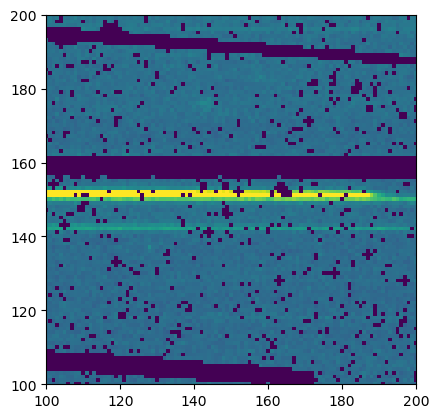

In [256]:
data = real_detectors['DET:10']
data_no_nan = np.nan_to_num(data, nan=0.0)

plt.imshow(data_no_nan, vmin=0, vmax=0.018, origin='lower')
# plt.imshow(real_detectors['DET:10'], vmin=0, vmax=0.018, origin='lower')
plt.xlim(100, 200)
plt.ylim(100, 200)
# plt.savefig("1_real.png")

(100.0, 200.0)

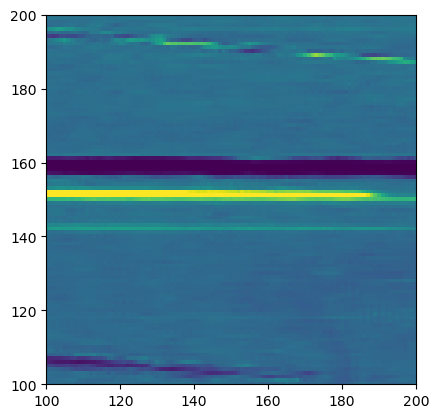

In [257]:
plt.imshow(pred_detectors['DET:10'], vmin=0, vmax=0.018, origin='lower')
plt.xlim(100, 200)
plt.ylim(100, 200)
# plt.savefig("1.png")

In [216]:
from tqdm.notebook import tqdm

residuals = {}

for d in tqdm(range(16)):
    residuals[f'DET:{d}'] = real_detectors[f'DET:{d}'] - pred_detectors[f'DET:{d}']

  0%|          | 0/16 [00:00<?, ?it/s]

In [218]:
residuals.keys()

dict_keys(['DET:0', 'DET:1', 'DET:2', 'DET:3', 'DET:4', 'DET:5', 'DET:6', 'DET:7', 'DET:8', 'DET:9', 'DET:10', 'DET:11', 'DET:12', 'DET:13', 'DET:14', 'DET:15'])

### Load the processed detector residuals to a new Gelsa frame

In [219]:
frame_residuals = G.new_spec_frame(ra=pt_ra, dec=pt_dec, pa=pt_pa, grism_name='RGS180', tilt=0)
frame_pred = G.new_spec_frame(ra=pt_ra, dec=pt_dec, pa=pt_pa, grism_name='RGS180', tilt=0)

In [220]:
frame_residuals._data = {}
frame_residuals._mask = {}
frame_residuals._var  = {}

frame_pred._data = {}
frame_pred._mask = {}
frame_pred._var  = {}

for d in range(16):
    img_res = residuals[f'DET:{d}']
    img_pred = pred_detectors[f'DET:{d}']

    frame_residuals._data[d] = img_res
    frame_residuals._mask[d] = masks[d]
    frame_residuals._var[d]  = variance[d]

    frame_pred._data[d] = img_pred
    frame_pred._mask[d] = masks[d]
    frame_pred._var[d]  = variance[d]

(300.0, 400.0)

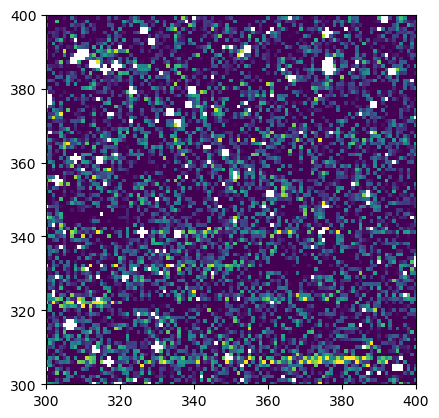

In [221]:
im, _, _ = frame_residuals.get_detector(13)
plt.imshow(im, vmin=0, vmax=0.001)
plt.xlim(300, 400)
plt.ylim(300, 400)

### Apply the spectrum extraction routine

In [222]:
import warnings
import astropy
from gelsa import analysis
from gelsa import visu

### Load the FULL EDFN_deep catalog with *redshift* measurements

In [223]:
warnings.filterwarnings('ignore', category=astropy.units.UnitsWarning, append=True)

DS = datastore.DataStore(# password_file='gelsa-extract-cosmos/.password',
                         # alternatively set username and password (can be empty string for local only)
                         username='', password='',
                         cachedir='/scratch/extra/ELSA/benjamin.granett/datastorecache'
                         )

area_list = {}

"""
# TR1 South
patch_id_list = [62, 67,71,74,78,107,111,115,123,126]
patch_id_list.sort()
"""

# EDFN North
patch_id_list = [38, 49, 57, 64, 99, 114, 151, 171]

# for patch_id in patch_id_list:
#    cat = DS.load_sel_catalog('EDFN_WIDE_SEL_R1',
#                              PatchId=patch_id,
#                              project='EUCLID',
#                              download_only=True
#                              )

cat = DS.load_sel_catalog('EDFN_DEEP_SEL_R1',
                          project='EUCLID',
                          CatalogOrigin='MEASURED_DEEP',
                         )

got username `` and password ***
EDFN_DEEP_SEL_R1 DpdLE3IDSELIDCatalog MEASURED_DEEP EUCLID None None
loaded /scratch/extra/ELSA/benjamin.granett/datastorecache/EUCLID/EDFN_DEEP_SEL_R1/DpdLE3IDSELIDCatalog/MEASURED_DEEP/cachecat_fb5b7bd09011bf3b32a5b6e1b4a8144f1075cd760f076a3b8a175bc719a68460.fits total rows 2749694


In [224]:
DS = datastore.DataStore(username='', password='',
                        cachedir='/scratch/astro/benjamin.granett/datastore'
                        )

got username `` and password ***


In [225]:
file_list = DS.load_sir_pack("DR1_R1", pointing_id_list=[30477])

DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30477, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30477'
got len(path_hits)=2


In [226]:
G = gelsa.Gelsa(config_file="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/gelsa_config.json", 
                calibdir="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/", zero_order_catalog=None)

## Load SIR science frame

In [227]:
frame_mf = G.load_frame(**file_list[0], apply_median_filter=True)

loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml


In [228]:
frame_pred.radec_to_pixel(pt_ra, pt_dec, wavelength=15000)

(1974.999740076454, 93.5435474204055, 5)

(0.0, 100.0)

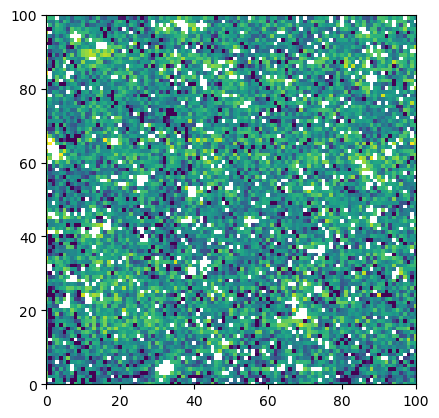

In [230]:
im,_,_ = frame_residuals.get_detector(11)
plt.imshow(visu.normalize_image(im, levels=(5, 99)))
plt.xlim(0,100)
plt.ylim(0,100)

In [231]:
x1, y1, det1 = frame_mf.radec_to_pixel(cat["RIGHT_ASCENSION"], 
                                    cat['DECLINATION'], 
                                    wavelength=12000)
x2, y2, det2 = frame_mf.radec_to_pixel(cat["RIGHT_ASCENSION"], 
                                    cat['DECLINATION'], 
                                    wavelength=19000)

In [232]:
on_frame_mask = (det1 == det2) & (det1 != -1) & (det2 != -1)

In [233]:
# Select only the sources whose spectrum is entirely on the loaded frame!
print(len(cat), "sources")
data_on_frame = cat[on_frame_mask]
print(len(data_on_frame), "sources on the frame with full spectrum in one detector")

# Select redshifts between 0.9 and 1.8
z_mask = (data_on_frame['SPE_Z'] > 0.9) & (data_on_frame['SPE_Z'] < 1.8)
data_on_frame = data_on_frame[z_mask]
print(len(data_on_frame), "sources with redshift between 0.9 and 1.8")

# Select bright enough sources -> good redshift measurements
h_alpha_mask = data_on_frame['FLUX_HALPHA_TOT_MWCORR'] > 5e-16
data_on_frame = data_on_frame[h_alpha_mask]
print(len(data_on_frame), "sources with H_alpha flux above 5e-16")
spe_z = data_on_frame['SPE_Z']

2749694 sources
40054 sources on the frame with full spectrum in one detector
11464 sources with redshift between 0.9 and 1.8
677 sources with H_alpha flux above 5e-16


In [182]:
print(data_on_frame.argsort(keys='FLUX_HALPHA_TOT_MWCORR'))

FLUX_HALPHA_TOT_MWCORR
----------------------
                   308
                   347
                   232
                   500
                    67
                   658
                   227
                   445
                    12
                   343
                   ...
                   176
                   256
                   458
                   366
                   373
                   644
                   599
                   670
                   508
                   268
                   144
Length = 677 rows


### Extract the spectrum of a selected source

In [234]:
options = dict(
    # wave_range=(9000, 14000),  # blue grism!
    wave_range=(12000, 19000), # red grism
    wave_step=10.,
    extraction_window_pix=20,
    # extraction_sigma_arcsec=3,
    ndrops=1000,
    pixel_shrink=1,
    # use_inv_var_weight=False,
    # extraction_profile='gauss',
    use_rel_flux_calib=True,
    super_sample=1,
    # median_filter_size_pix=40,
    # apply_median_filter=True,
    # apply_persistence_correction=False,
    # persistence_mask_threshold=0,
)

def extract(frame, ra, dec):
    """ """
    spec2d, spec2d_var, spec2d_n, spec2d_pix_bins = frame.resample_on_wavelength(ra, dec, **options)
    spec2d_counts = spec2d_n > 0

    valid = spec2d_n > 0
    out = np.zeros(spec2d.shape)
    out_var = np.zeros(spec2d.shape)
    out[valid] = spec2d[valid]/spec2d_n[valid]
    out_var[valid] = spec2d_var[valid]/spec2d_n[valid]**2

    spec_pack = {
            'spec2d': out,
            'spec2d_var': out_var,
            'spec2d_norm': spec2d_n,
            'spec2d_counts': spec2d_counts,
            'wave_bins': spec2d_pix_bins[1],
            'pix_bins': spec2d_pix_bins[0],
            }
   
    pix_perp = (spec2d_pix_bins[0][1:] + spec2d_pix_bins[0][:-1])/2.
    wave = (spec2d_pix_bins[1][1:] + spec2d_pix_bins[1][:-1])/2.

    spec_pack['pixel_perp'] = pix_perp
    spec_pack['wavelength'] = wave
    
    spec1d_pack = analysis.Analysis.extract_spec2d_to_1d(spec_pack, pix_scale=0.3)

    return spec1d_pack, spec_pack

In [235]:
n = 12
print("Selected source is on detector", det1[on_frame_mask][n])

Selected source is on detector 3


In [236]:
# define coordinates of target galaxy
ra = data_on_frame["RIGHT_ASCENSION"][n]
dec = data_on_frame["DECLINATION"][n]

# Choose z from the catalog !
redshift = spe_z[n]

# run extraction routine
spec1d_pack_mf, spec2d_pack_mf = extract(frame_mf, ra, dec)
spec1d_pack_ml, spec2d_pack_ml = extract(frame_residuals, ra, dec)
spec1d_pack_original, spec2d_pack_original = extract(frame, ra, dec)
spec1d_pack_pred, spec2d_pack_pred = extract(frame_pred, ra, dec)

Applying median filter with size 40 pixels and tilt=0
theshold 80
Percentiles (95, 99, 99.5) [ 31.60576305  91.00747093 221.27709137]
median artifact masked pixel fraction: 0.01121


In [237]:
spec2d_pack_mf.update(spec1d_pack_mf)
spec2d_pack_ml.update(spec1d_pack_ml)
spec2d_pack_original.update(spec1d_pack_original)
spec2d_pack_pred.update(spec1d_pack_pred)
# Now spec2d_pack is the combined dictionary

# Give it an easier name
pack_mf = spec2d_pack_mf
pack_ml = spec2d_pack_ml
pack = spec2d_pack_original
pack_pred = spec2d_pack_pred

Text(0.5, 1.0, 'U-Net prediction - no continuum subtraction')

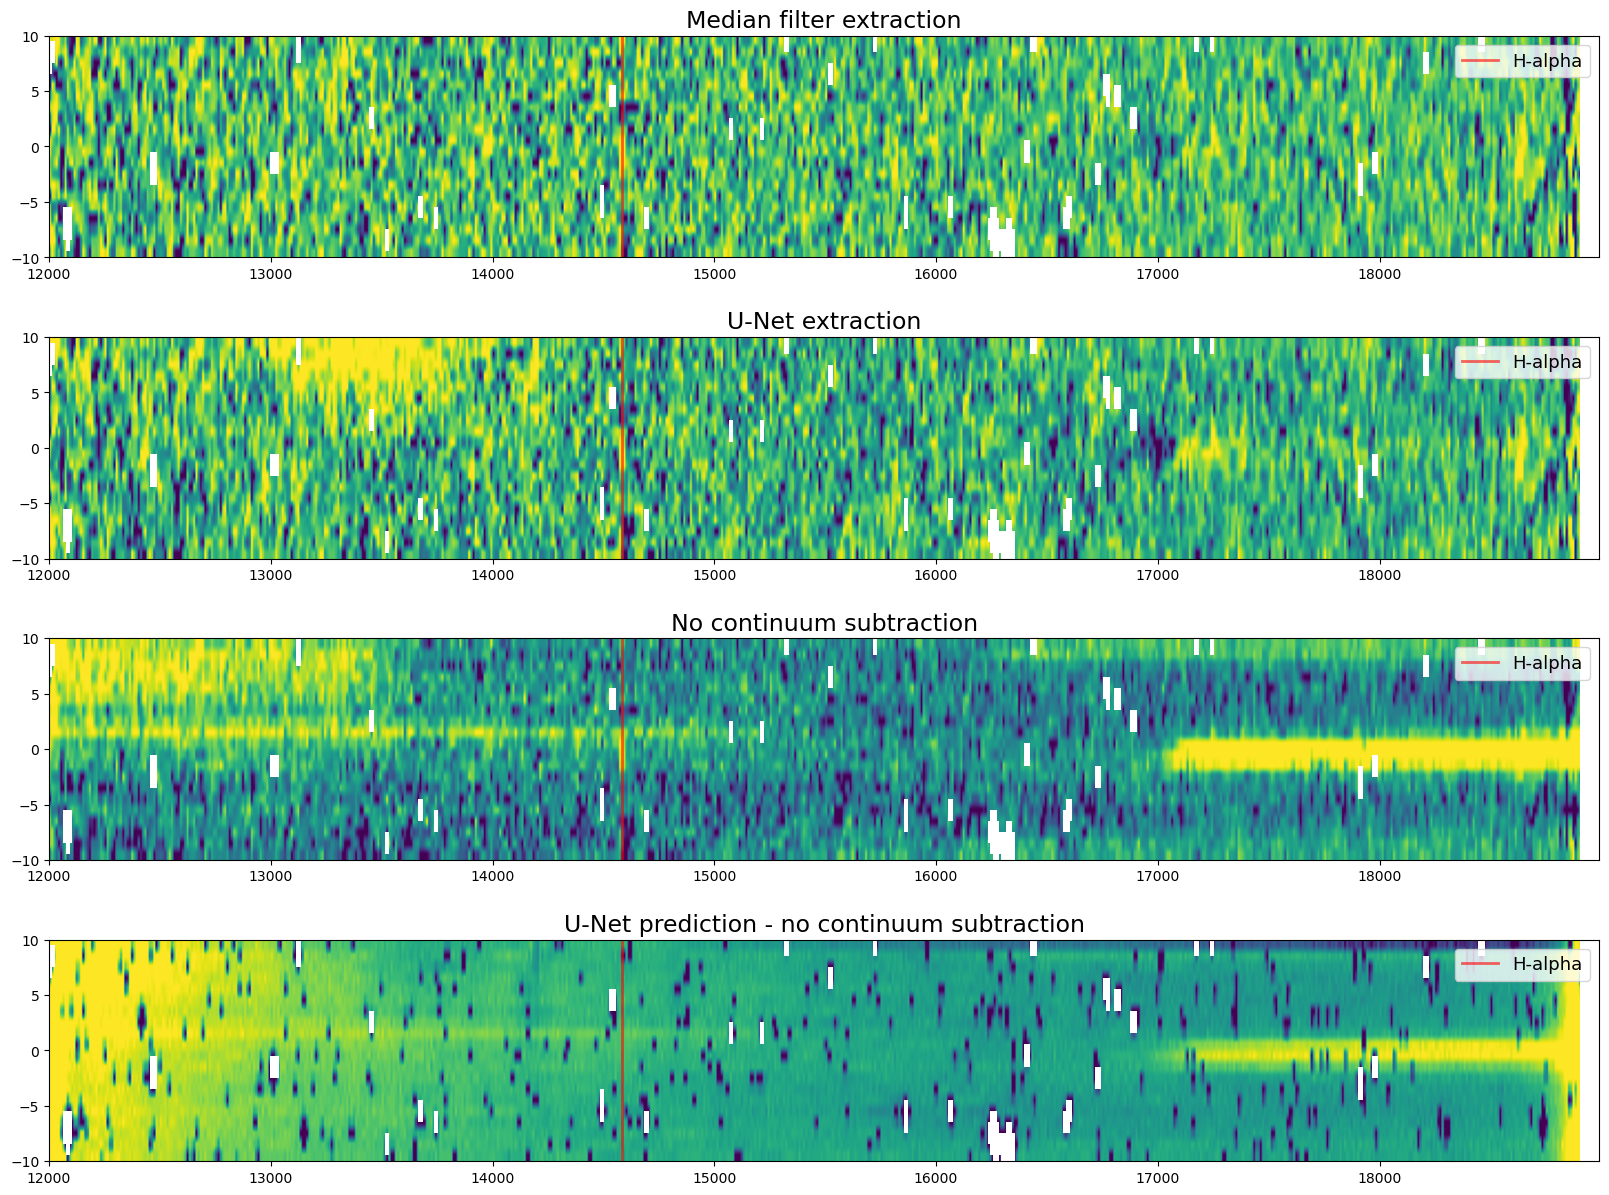

In [238]:
# plot the 2D spectrum
wave = pack_mf['wave_bins']
ybins = pack_mf['pix_bins']

plt.subplots(4, 1, figsize=(20, 15))

spec2d = pack_mf['spec2d']
spec2d_ml = pack_ml['spec2d']
spec2d_original = pack['spec2d']
spec2d_pred = pack_pred['spec2d']

bad = pack_mf['spec2d_norm'] == 0
spec2d[bad] = float('nan')

bad_ml = pack_ml['spec2d_norm'] == 0
spec2d_ml[bad_ml] = float('nan')

bad_or = pack['spec2d_norm'] == 0
spec2d_original[bad_or] = float('nan')

bad_pred = pack_pred['spec2d_norm'] == 0
spec2d_pred[bad_pred] = float('nan')

plt.subplot(411)
plt.imshow(visu.normalize_image(spec2d, levels=(5, 95)), origin='lower', aspect=50, 
          extent=(wave[0], wave[-1], ybins[0], ybins[-1]))

plt.axvline(6564*(1+redshift), c='red', lw=2, alpha=0.6, label='H-alpha')
plt.legend(fontsize=13)
plt.title('Median filter extraction', fontsize=17)

plt.subplot(412)
plt.imshow(visu.normalize_image(spec2d_ml, levels=(5, 95)), origin='lower', aspect=50, 
          extent=(wave[0], wave[-1], ybins[0], ybins[-1]))

plt.axvline(6564*(1+redshift), c='red', lw=2, alpha=0.6, label='H-alpha')
plt.legend(fontsize=13)
plt.title('U-Net extraction', fontsize=17)

plt.subplot(413)
plt.imshow(visu.normalize_image(spec2d_original, levels=(5, 95)), origin='lower', aspect=50, 
          extent=(wave[0], wave[-1], ybins[0], ybins[-1]))

plt.axvline(6564*(1+redshift), c='red', lw=2, alpha=0.6, label='H-alpha')
plt.legend(fontsize=13)
plt.title('No continuum subtraction', fontsize=17)

plt.subplot(414)
plt.imshow(visu.normalize_image(spec2d_pred, levels=(5, 95)), origin='lower', aspect=50, 
          extent=(wave[0], wave[-1], ybins[0], ybins[-1]))

plt.axvline(6564*(1+redshift), c='red', lw=2, alpha=0.6, label='H-alpha')
plt.legend(fontsize=13)
plt.title('U-Net prediction - no continuum subtraction', fontsize=17)

# plt.savefig('extraction_example.png')

In [157]:
np.nanmax(spec2d_ml)

4.175215489959102e-23

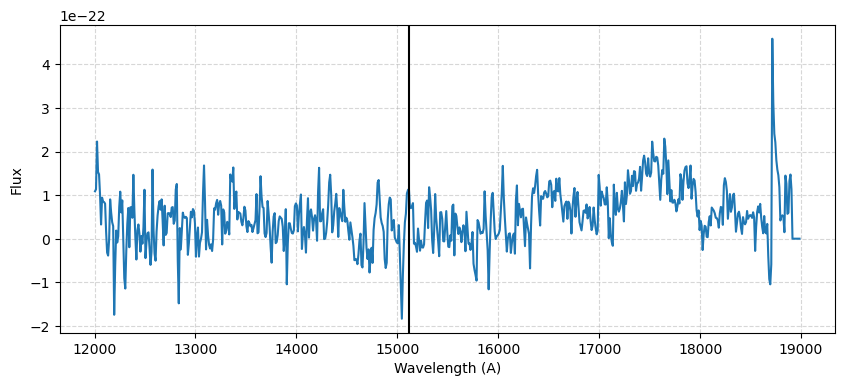

In [102]:
wave_bins = pack_ml['wave_bins']
x = (wave_bins[1:]+wave_bins[:-1])/2.

plt.figure(figsize=(10,4))
# plt.plot(x, pack_mf['spec1d'])
plt.plot(x, pack_ml['spec1d'])

# Visualize H-alpha
plt.axvline(6564*(1+redshift), c='k')

plt.xlabel("Wavelength (A)")
plt.ylabel("Flux")

plt.grid(True, alpha=0.5, ls='--')

In [266]:
np.nanmin(real_detectors['DET:0'])

0.0

In [267]:
np.nanmin(pred_detectors['DET:0'])

9.176071e-10